In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/amazon-stock-data/Amazon_Stock_Data.csv


In [6]:
import pandas as pd
data=pd.read_csv('/kaggle/input/amazon-stock-data/Amazon_Stock_Data.csv',delimiter=',')
print(data.head())
data.shape

        Price           Adj Close               Close                High  \
0      Ticker                AMZN                AMZN                AMZN   
1        Date                 NaN                 NaN                 NaN   
2  2015-01-02  15.425999641418457  15.425999641418457  15.737500190734863   
3  2015-01-05   15.10949993133545   15.10949993133545  15.418999671936035   
4  2015-01-06   14.76449966430664   14.76449966430664  15.149999618530273   

                  Low                Open    Volume  
0                AMZN                AMZN      AMZN  
1                 NaN                 NaN       NaN  
2  15.347999572753906  15.628999710083008  55664000  
3  15.042499542236328  15.350500106811523  55484000  
4  14.619000434875488  15.112000465393066  70380000  


(2503, 7)

In [7]:
data.columns

Index(['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [8]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
data=pd.read_csv('/kaggle/input/amazon-stock-data/Amazon_Stock_Data.csv',skiprows=2)
data.columns = ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
data.dropna(subset=['Date'], inplace=True)
for col in ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']:
    data[col] = pd.to_numeric(data[col], errors='coerce')
data.dropna(subset=['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], inplace=True)
scaler = MinMaxScaler()
data[['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']] = scaler.fit_transform(data[['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']])
data.set_index('Date', inplace=True)
print(data)


            Adj Close     Close      High       Low      Open    Volume
Date                                                                   
2015-01-02   0.005071  0.005071  0.005558  0.005135  0.006177  0.082782
2015-01-05   0.003583  0.003583  0.004080  0.003690  0.004869  0.082390
2015-01-06   0.001961  0.001961  0.002832  0.001686  0.003748  0.114808
2015-01-07   0.002697  0.002697  0.002433  0.002384  0.002635  0.076562
2015-01-08   0.003176  0.003176  0.002865  0.002569  0.003297  0.096066
...               ...       ...       ...       ...       ...       ...
2024-12-03   0.936102  0.936102  0.925490  0.924222  0.920618  0.031750
2024-12-04   0.958295  0.958295  0.953234  0.953076  0.947157  0.067726
2024-12-05   0.969532  0.969532  0.963209  0.960408  0.956880  0.051174
2024-12-06   1.000000  1.000000  0.986406  0.976018  0.969657  0.057785
2024-12-09   0.995580  0.995580  1.000000  1.000000  1.000000  0.063433

[2501 rows x 6 columns]


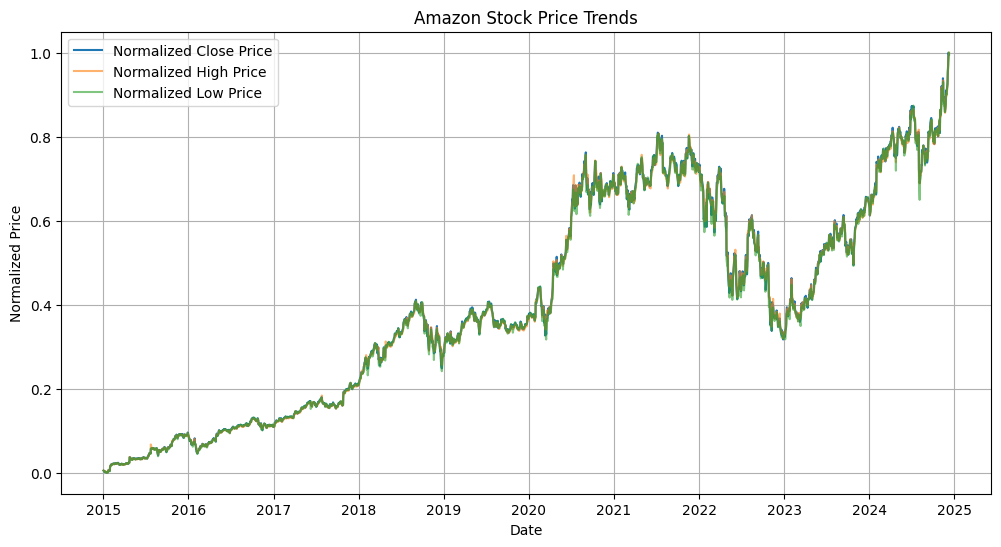

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data.index, data['Close'], label='Normalized Close Price')
plt.plot(data.index, data['High'], label='Normalized High Price', alpha=0.6)
plt.plot(data.index, data['Low'], label='Normalized Low Price', alpha=0.6)
plt.title('Amazon Stock Price Trends')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend()
plt.grid(True)
plt.show()
